In [23]:
from evaluate_classifier import evaluate_classifier

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

In [25]:
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")

In [26]:
X = dataset.drop("sii", axis=1)
y = dataset["sii"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7839, 32)
Target shape: (7839,)


In [27]:
target_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "proportion": y.value_counts(normalize=True).sort_index()
})

target_distribution

,count,proportion
sii,,
0,5476,0.698558
1,1444,0.184207
2,846,0.107922
3,73,0.009312


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.107891
3    0.009295
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.107993
3    0.009354
Name: proportion, dtype: float64


In [29]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

## Base SVM

In [30]:
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

svm_base.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('clf', SVC(random_state=42))])

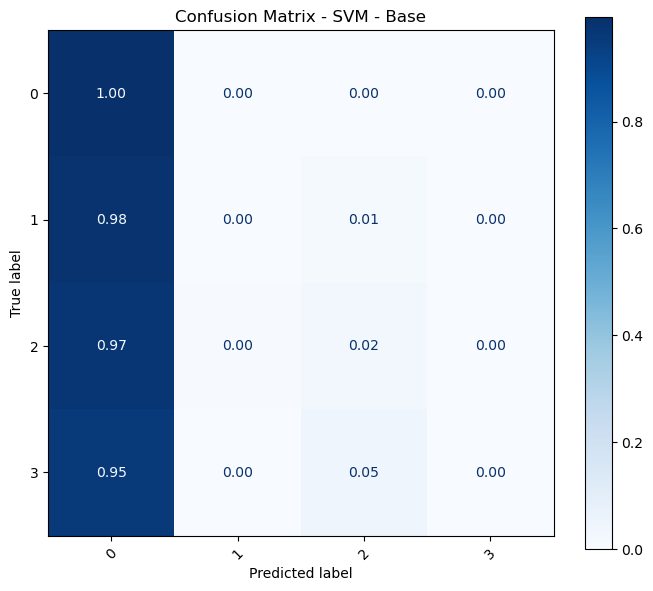


Classification report - SVM - Base


,precision,recall,f1-score,support
0,0.702274,0.996348,0.823855,1643.00000
1,0.200000,0.002309,0.004566,433.00000
2,0.375000,0.023622,0.044444,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.698980,0.698980,0.698980,0.69898
macro avg,0.319318,0.255570,0.218216,2352.00000
weighted avg,0.567894,0.698980,0.581148,2352.00000


In [31]:
results_svm_base, report_svm_base = evaluate_classifier(
    model=svm_base,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Base",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

In [32]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

linear_svm_c_results = []

for C in C_values:
    linear_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=C,
            random_state=42,
            max_iter=20000
        ))
    ])
    
    scores = cross_validate(
        linear_svm,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=-1
    )
    
    linear_svm_c_results.append({
        "model": f"Linear SVM C={C}",
        "C": C,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean()
    })

linear_svm_c_results_df = pd.DataFrame(linear_svm_c_results)

linear_svm_c_results_df.sort_values("f1_macro", ascending=False)

,model,C,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,Linear SVM C=0.001,0.001,0.696373,0.263373,0.236427,0.591224
1,Linear SVM C=0.01,0.010,0.696920,0.261960,0.233536,0.590029
2,Linear SVM C=0.1,0.100,0.696738,0.261895,0.233447,0.589917
3,Linear SVM C=1,1.000,0.696738,0.261895,0.233447,0.589917
4,Linear SVM C=10,10.000,0.696738,0.261895,0.233447,0.589917
5,Linear SVM C=100,100.000,0.696738,0.261895,0.233447,0.589917


In [33]:
linear_svm_balanced_c_results = []

for C in C_values:
    linear_svm_balanced = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=C,
            class_weight="balanced",
            random_state=42,
            max_iter=20000
        ))
    ])
    
    scores = cross_validate(
        linear_svm_balanced,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=-1
    )
    
    linear_svm_balanced_c_results.append({
        "model": f"Linear SVM Balanced C={C}",
        "C": C,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean()
    })

linear_svm_balanced_c_results_df = pd.DataFrame(linear_svm_balanced_c_results)

linear_svm_balanced_c_results_df.sort_values("f1_macro", ascending=False)

,model,C,accuracy,balanced_accuracy,f1_macro,f1_weighted
1,Linear SVM Balanced C=0.01,0.010,0.644068,0.347225,0.314209,0.617154
3,Linear SVM Balanced C=1,1.000,0.642610,0.345459,0.312980,0.616228
4,Linear SVM Balanced C=10,10.000,0.642610,0.345459,0.312980,0.616228
5,Linear SVM Balanced C=100,100.000,0.642610,0.345459,0.312980,0.616228
2,Linear SVM Balanced C=0.1,0.100,0.642245,0.345146,0.312419,0.615773
0,Linear SVM Balanced C=0.001,0.001,0.643521,0.346655,0.311377,0.614414


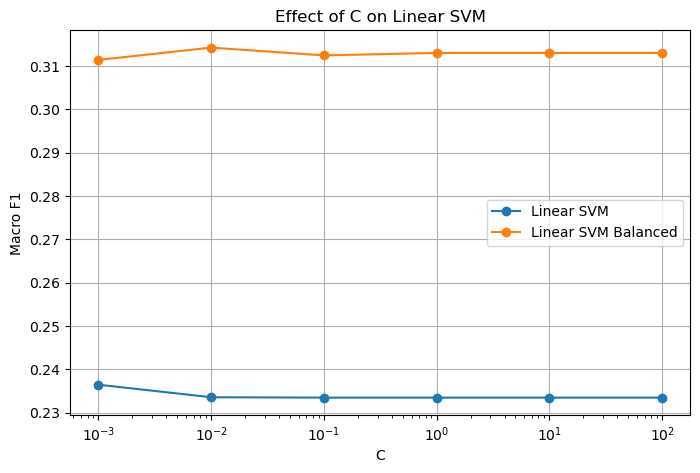

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    linear_svm_c_results_df["C"],
    linear_svm_c_results_df["f1_macro"],
    marker="o",
    label="Linear SVM"
)

plt.plot(
    linear_svm_balanced_c_results_df["C"],
    linear_svm_balanced_c_results_df["f1_macro"],
    marker="o",
    label="Linear SVM Balanced"
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Macro F1")
plt.title("Effect of C on Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

## Tuned SVM without imbalance correction

In [35]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42))
])

param_grid_svm = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"]
    }
]

grid_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_svm.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.3s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.3s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.4s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.5s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.5s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.5s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.7s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.7s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.6s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   0.7s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   0.8s
[CV] END ........clf__C=1, clf__gamma=scale, clf_

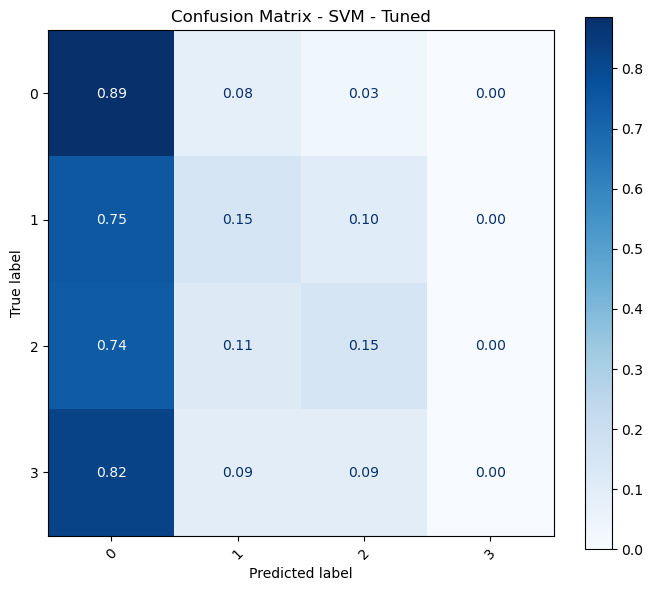


Classification report - SVM - Tuned


,precision,recall,f1-score,support
0,0.733132,0.886184,0.802425,1643.00000
1,0.278761,0.145497,0.191199,433.00000
2,0.273381,0.149606,0.193384,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.661990,0.661990,0.661990,0.66199
macro avg,0.321319,0.295322,0.296752,2352.00000
weighted avg,0.592975,0.661990,0.616621,2352.00000


In [36]:
best_svm = grid_svm.best_estimator_

results_svm_tuned, report_svm_tuned = evaluate_classifier(
    model=best_svm,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with class weight balanced

In [37]:
svm_balanced_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42))
])

param_grid_svm_balanced = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10],
        "clf__class_weight": ["balanced"]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"],
        "clf__class_weight": ["balanced"]
    }
]

grid_svm_balanced = GridSearchCV(
    estimator=svm_balanced_pipe,
    param_grid=param_grid_svm_balanced,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_balanced.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_balanced.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_svm_balanced.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.7s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.7s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.7s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.2s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.3s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.3s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.2s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.2s
[CV] END clf__C=1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.0s
[CV] END clf__C=1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.0s
[CV] END c

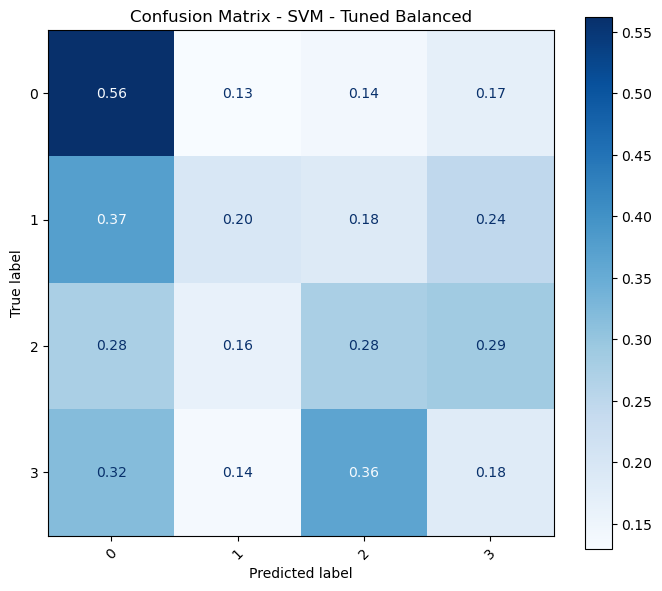


Classification report - SVM - Tuned Balanced


,precision,recall,f1-score,support
0,0.794497,0.562386,0.658589,1643.000000
1,0.248538,0.196305,0.219355,433.000000
2,0.179949,0.275591,0.217729,254.000000
3,0.008734,0.181818,0.016667,22.000000
accuracy,0.460459,0.460459,0.460459,0.460459
macro avg,0.307929,0.304025,0.278085,2352.000000
weighted avg,0.620270,0.460459,0.524112,2352.000000


In [38]:
best_svm_balanced = grid_svm_balanced.best_estimator_

results_svm_balanced_tuned, report_svm_balanced_tuned = evaluate_classifier(
    model=best_svm_balanced,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Tuned Balanced",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with SMOTE

In [39]:
svm_smote_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(random_state=42))
])

param_grid_svm_smote = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10],
        "smote__k_neighbors": [3, 5]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"],
        "smote__k_neighbors": [3, 5]
    }
]

grid_svm_smote = GridSearchCV(
    estimator=svm_smote_pipe,
    param_grid=param_grid_svm_smote,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_smote.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_smote.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_svm_smote.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   6.4s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   6.5s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   6.6s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   6.6s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   6.7s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   6.8s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=  14.1s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=  14.3s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=  14.5s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=5; total time=  14.2s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=5; total time=  14.4s
[CV] END .clf__C=1, clf__kernel=linear, sm

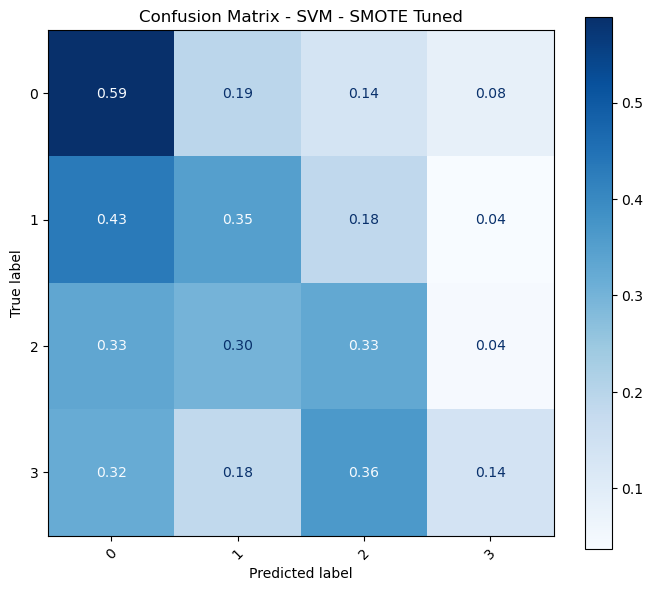


Classification report - SVM - SMOTE Tuned


,precision,recall,f1-score,support
0,0.777510,0.589166,0.670360,1643.00000
1,0.275046,0.348730,0.307536,433.00000
2,0.211196,0.326772,0.256569,254.00000
3,0.018182,0.136364,0.032086,22.00000
accuracy,0.512330,0.512330,0.512330,0.51233
macro avg,0.320483,0.350258,0.316638,2352.00000
weighted avg,0.616746,0.512330,0.552908,2352.00000


In [40]:
best_svm_smote = grid_svm_smote.best_estimator_

results_svm_smote_tuned, report_svm_smote_tuned = evaluate_classifier(
    model=best_svm_smote,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - SMOTE Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with SMOTE-Tomek

In [41]:
svm_smote_tomek_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("clf", SVC(random_state=42))
])

param_grid_svm_smote_tomek = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"]
    }
]

grid_svm_smote_tomek = GridSearchCV(
    estimator=svm_smote_tomek_pipe,
    param_grid=param_grid_svm_smote_tomek,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_smote_tomek.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_smote_tomek.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_svm_smote_tomek.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   9.1s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   9.1s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   9.3s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=  16.3s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=  17.5s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=  17.5s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   9.6s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=  10.5s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   8.5s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   8.7s
[CV] END .......clf__C=10, clf__gamma=scale, clf__kernel=rbf; total time=   7.5s
[CV] END ........clf__C=1, clf__gamma=scale, clf_

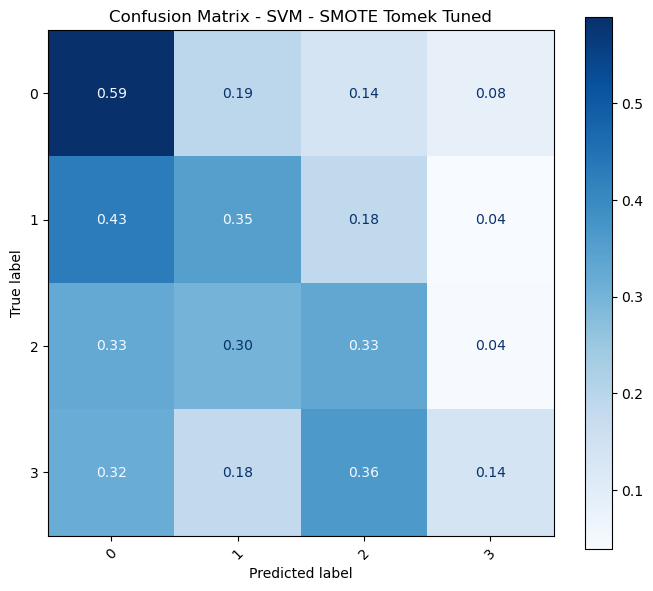


Classification report - SVM - SMOTE Tomek Tuned


,precision,recall,f1-score,support
0,0.778761,0.589166,0.670825,1643.000000
1,0.275547,0.348730,0.307849,433.000000
2,0.213198,0.330709,0.259259,254.000000
3,0.017964,0.136364,0.031746,22.000000
accuracy,0.512755,0.512755,0.512755,0.512755
macro avg,0.321368,0.351242,0.317420,2352.000000
weighted avg,0.617927,0.512755,0.553577,2352.000000


In [42]:
best_svm_smote_tomek = grid_svm_smote_tomek.best_estimator_

results_svm_smote_tomek_tuned, report_svm_smote_tomek_tuned = evaluate_classifier(
    model=best_svm_smote_tomek,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - SMOTE Tomek Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Final comparison

In [43]:
svm_results_table = pd.DataFrame([
    results_svm_base,
    results_svm_tuned,
    results_svm_balanced_tuned,
    results_svm_smote_tuned,
    results_svm_smote_tomek_tuned
])

svm_results_table = svm_results_table.sort_values("f1_macro", ascending=False)

svm_results_table

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,roc_auc_ovr_weighted,roc_auc_ovr_macro
4,SVM - SMOTE Tomek Tuned,0.512755,0.351242,0.617927,0.512755,0.553577,0.321368,0.351242,0.317420,0.619934,0.659876
3,SVM - SMOTE Tuned,0.512330,0.350258,0.616746,0.512330,0.552908,0.320483,0.350258,0.316638,0.619753,0.659738
1,SVM - Tuned,0.661990,0.295322,0.592975,0.661990,0.616621,0.321319,0.295322,0.296752,0.635091,0.625755
2,SVM - Tuned Balanced,0.460459,0.304025,0.620270,0.460459,0.524112,0.307929,0.304025,0.278085,0.622214,0.608020
0,SVM - Base,0.698980,0.255570,0.567894,0.698980,0.581148,0.319318,0.255570,0.218216,0.630940,0.624121


In [3]:
from evaluate_classifier import evaluate_classifier

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN

In [4]:
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")

X = dataset.drop("sii", axis=1)
y_4class = dataset["sii"]

# 3-class version: 0 -> 0, 1 -> 1, 2 and 3 -> 2
y_3class = y_4class.copy()
y_3class = y_3class.replace({3: 2})

print("4-class distribution:")
print(y_4class.value_counts(normalize=True).sort_index())

print("\n3-class distribution:")
print(y_3class.value_counts(normalize=True).sort_index())

4-class distribution:
sii
0    0.698558
1    0.184207
2    0.107922
3    0.009312
Name: proportion, dtype: float64

3-class distribution:
sii
0    0.698558
1    0.184207
2    0.117234
Name: proportion, dtype: float64


In [7]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [2]:
def run_svm_experiment(
    X,
    y,
    problem_name,
    kernel_type="linear",
    imbalance=False,
    test_size=0.3,
    random_state=42,
    cv=None,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
):
    print("=" * 90)
    print(problem_name)
    print("=" * 90)

    # ------------------------------------------------------------
    # Train/test split
    # ------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    print("\nTrain target distribution:")
    print(y_train.value_counts(normalize=True).sort_index())

    print("\nTest target distribution:")
    print(y_test.value_counts(normalize=True).sort_index())

    labels = np.sort(y.unique())

    # ------------------------------------------------------------
    # Parameter grid
    # ------------------------------------------------------------
    if kernel_type == "linear":
        base_param_grid = {
            "clf__kernel": ["linear"],
            "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]
        }

    elif kernel_type == "nonlinear":
        base_param_grid = {
            "clf__kernel": ["rbf"],
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", 0.01, 0.1, 1]
        }

    else:
        raise ValueError("kernel_type must be either 'linear' or 'nonlinear'.")

    # ------------------------------------------------------------
    # Imbalance strategies
    # Each strategy is a list of pipeline steps
    # ------------------------------------------------------------
    if imbalance:
        resampling_strategies = {
            "Class Weight Balanced": [],

            "SMOTE": [
                ("smote", SMOTE(random_state=random_state, k_neighbors=3))
            ],

            "ADASYN": [
                ("adasyn", ADASYN(random_state=random_state, n_neighbors=3))
            ],

            "SMOTE + Tomek": [
                ("smote", SMOTE(random_state=random_state, k_neighbors=3)),
                ("tomek", TomekLinks())
            ],

            "ADASYN + Tomek": [
                ("adasyn", ADASYN(random_state=random_state, n_neighbors=3)),
                ("tomek", TomekLinks())
            ],

            "SMOTE + ENN": [
                ("smote", SMOTE(random_state=random_state, k_neighbors=3)),
                ("enn", EditedNearestNeighbours(n_neighbors=3))
            ],

            "ADASYN + ENN": [
                ("adasyn", ADASYN(random_state=random_state, n_neighbors=3)),
                ("enn", EditedNearestNeighbours(n_neighbors=3))
            ]
        }
    else:
        resampling_strategies = {
            "No Imbalance Correction": []
        }

    all_grids = {}
    cv_results = []

    # ------------------------------------------------------------
    # Grid search for each strategy
    # ------------------------------------------------------------
    for strategy_name, sampler_steps in resampling_strategies.items():

        print("\n" + "-" * 90)
        print("Strategy:", strategy_name)
        print("-" * 90)

        steps = [
            ("scaler", StandardScaler())
        ]

        steps.extend(sampler_steps)

        steps.append((
            "clf",
            SVC(random_state=random_state)
        ))

        pipe = ImbPipeline(steps=steps)

        param_grid = base_param_grid.copy()

        if imbalance and strategy_name == "Class Weight Balanced":
            param_grid["clf__class_weight"] = ["balanced"]
        else:
            param_grid["clf__class_weight"] = [None]

        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="balanced_accuracy",
            cv=cv,
            n_jobs=-1,
            verbose=1,
            error_score=np.nan
        )

        grid_search.fit(X_train, y_train)

        print("Best parameters:")
        print(grid_search.best_params_)

        print("\nBest CV balanced accuracy:")
        print(grid_search.best_score_)

        all_grids[strategy_name] = grid_search

        cv_results.append({
            "problem": problem_name,
            "kernel_type": kernel_type,
            "imbalance": imbalance,
            "strategy": strategy_name,
            "best_cv_balanced_accuracy": grid_search.best_score_,
            "best_params": grid_search.best_params_
        })

    cv_results_df = pd.DataFrame(cv_results).sort_values(
        "best_cv_balanced_accuracy",
        ascending=False
    )

    print("\nCV results:")
    display(cv_results_df)

    # ------------------------------------------------------------
    # Best model selection
    # ------------------------------------------------------------
    best_strategy = cv_results_df.iloc[0]["strategy"]
    best_grid = all_grids[best_strategy]
    best_model = best_grid.best_estimator_

    print("\nBest strategy:")
    print(best_strategy)

    print("\nBest parameters:")
    print(best_grid.best_params_)

    print("\nBest CV balanced accuracy:")
    print(best_grid.best_score_)

    # ------------------------------------------------------------
    # Final evaluation with evaluate_classifier
    # ------------------------------------------------------------
    results_best, report_best = evaluate_classifier(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        model_name=f"{problem_name} - Best Strategy: {best_strategy}",
        labels=labels,
        average="weighted",
        plot_confusion=plot_confusion,
        plot_roc=plot_roc,
        plot_pr=plot_pr,
        normalize_cm="true"
    )

    # ------------------------------------------------------------
    # Evaluation of best model for each strategy
    # ------------------------------------------------------------
    test_results_all = []

    for strategy_name, grid_search in all_grids.items():

        model_tmp = grid_search.best_estimator_

        results_tmp, report_tmp = evaluate_classifier(
            model=model_tmp,
            X_test=X_test,
            y_test=y_test,
            model_name=f"{problem_name} - {strategy_name}",
            labels=labels,
            average="weighted",
            plot_confusion=False,
            plot_roc=False,
            plot_pr=False,
            normalize_cm="true"
        )

        results_tmp["problem"] = problem_name
        results_tmp["kernel_type"] = kernel_type
        results_tmp["imbalance"] = imbalance
        results_tmp["strategy"] = strategy_name
        results_tmp["best_cv_balanced_accuracy"] = grid_search.best_score_
        results_tmp["best_params"] = grid_search.best_params_

        test_results_all.append(results_tmp)

    test_results_all_df = pd.DataFrame(test_results_all)

    if "balanced_accuracy" in test_results_all_df.columns:
        test_results_all_df = test_results_all_df.sort_values(
            "balanced_accuracy",
            ascending=False
        )

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "all_grids": all_grids,
        "cv_results": cv_results_df,
        "best_strategy": best_strategy,
        "best_grid": best_grid,
        "best_model": best_model,
        "results_best": results_best,
        "report_best": report_best,
        "test_results_all": test_results_all_df
    }

Linear SVM - 3 Classes - Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.117186
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.117347
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: Class Weight Balanced
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters:
{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}

Best CV balanced accuracy:
0.4704728342449355

------------------------------------------------------------------------------------------
Strategy: SMOTE
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters:
{'clf__

,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
5,Linear SVM - 3 Classes - Imbalance Handling,linear,True,SMOTE + ENN,0.475166,"{'clf__C': 0.001, 'clf__class_weight': None, '..."
2,Linear SVM - 3 Classes - Imbalance Handling,linear,True,ADASYN,0.471627,"{'clf__C': 0.01, 'clf__class_weight': None, 'c..."
4,Linear SVM - 3 Classes - Imbalance Handling,linear,True,ADASYN + Tomek,0.471490,"{'clf__C': 0.01, 'clf__class_weight': None, 'c..."
3,Linear SVM - 3 Classes - Imbalance Handling,linear,True,SMOTE + Tomek,0.470934,"{'clf__C': 0.001, 'clf__class_weight': None, '..."
0,Linear SVM - 3 Classes - Imbalance Handling,linear,True,Class Weight Balanced,0.470473,"{'clf__C': 100, 'clf__class_weight': 'balanced..."
1,Linear SVM - 3 Classes - Imbalance Handling,linear,True,SMOTE,0.470358,"{'clf__C': 0.01, 'clf__class_weight': None, 'c..."
6,Linear SVM - 3 Classes - Imbalance Handling,linear,True,ADASYN + ENN,0.451315,"{'clf__C': 0.001, 'clf__class_weight': None, '..."



Best strategy:
SMOTE + ENN

Best parameters:
{'clf__C': 0.001, 'clf__class_weight': None, 'clf__kernel': 'linear'}

Best CV balanced accuracy:
0.4751655558283266


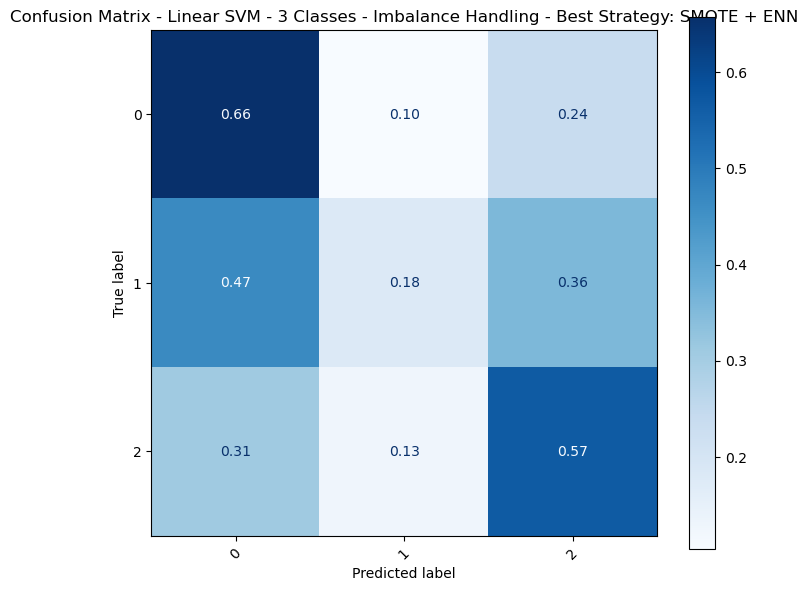


Classification report - Linear SVM - 3 Classes - Imbalance Handling - Best Strategy: SMOTE + ENN


,precision,recall,f1-score,support
0,0.790205,0.657943,0.718034,1643.000000
1,0.272085,0.177829,0.215084,433.000000
2,0.222539,0.565217,0.319345,276.000000
accuracy,0.558673,0.558673,0.558673,0.558673
macro avg,0.428276,0.466996,0.417488,2352.000000
weighted avg,0.628206,0.558673,0.578657,2352.000000



Classification report - Linear SVM - 3 Classes - Imbalance Handling - Class Weight Balanced


,precision,recall,f1-score,support
0,0.793954,0.607425,0.688276,1643.000000
1,0.253898,0.263279,0.258503,433.000000
2,0.224458,0.525362,0.314534,276.000000
accuracy,0.534439,0.534439,0.534439,0.534439
macro avg,0.424103,0.465356,0.420438,2352.000000
weighted avg,0.627702,0.534439,0.565298,2352.000000



Classification report - Linear SVM - 3 Classes - Imbalance Handling - SMOTE


...

,precision,recall,f1-score,support
0,0.805137,0.553256,0.655844,1643.000000
1,0.237838,0.304850,0.267206,433.000000
2,0.215569,0.521739,0.305085,276.000000
accuracy,0.503827,0.503827,0.503827,0.503827
macro avg,0.419515,0.459948,0.409378,2352.000000
weighted avg,0.631514,0.503827,0.543136,2352.000000



Classification report - Linear SVM - 3 Classes - Imbalance Handling - SMOTE + ENN


,precision,recall,f1-score,support
0,0.790205,0.657943,0.718034,1643.000000
1,0.272085,0.177829,0.215084,433.000000
2,0.222539,0.565217,0.319345,276.000000
accuracy,0.558673,0.558673,0.558673,0.558673
macro avg,0.428276,0.466996,0.417488,2352.000000
weighted avg,0.628206,0.558673,0.578657,2352.000000



Classification report - Linear SVM - 3 Classes - Imbalance Handling - ADASYN + ENN


,precision,recall,f1-score,support
0,0.795420,0.634206,0.705723,1643.000000
1,0.273273,0.210162,0.237598,433.000000
2,0.220028,0.565217,0.316751,276.000000
accuracy,0.548044,0.548044,0.548044,0.548044
macro avg,0.429574,0.469862,0.420024,2352.000000
weighted avg,0.631773,0.548044,0.573897,2352.000000


In [50]:
linear_svm_3class_imbalance = run_svm_experiment(
    X=X,
    y=y_3class,
    problem_name="Linear SVM - 3 Classes - Imbalance Handling",
    kernel_type="linear",
    imbalance=True,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)

Non-linear SVM - 4 Classes - No Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.107891
3    0.009295
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.107993
3    0.009354
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: No Imbalance Correction
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters:
{'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.29582475291356963

CV results:


,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
0,Non-linear SVM - 4 Classes - No Imbalance Hand...,nonlinear,False,No Imbalance Correction,0.295825,"{'clf__C': 10, 'clf__class_weight': None, 'clf..."



Best strategy:
No Imbalance Correction

Best parameters:
{'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.29582475291356963


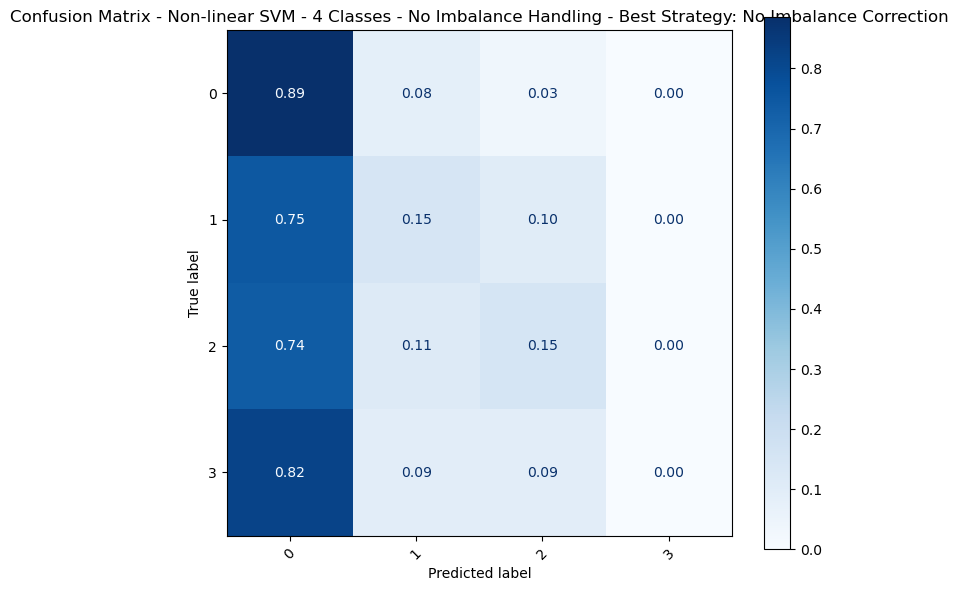


Classification report - Non-linear SVM - 4 Classes - No Imbalance Handling - Best Strategy: No Imbalance Correction


,precision,recall,f1-score,support
0,0.733132,0.886184,0.802425,1643.00000
1,0.278761,0.145497,0.191199,433.00000
2,0.273381,0.149606,0.193384,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.661990,0.661990,0.661990,0.66199
macro avg,0.321319,0.295322,0.296752,2352.00000
weighted avg,0.592975,0.661990,0.616621,2352.00000



Classification report - Non-linear SVM - 4 Classes - No Imbalance Handling - No Imbalance Correction


,precision,recall,f1-score,support
0,0.733132,0.886184,0.802425,1643.00000
1,0.278761,0.145497,0.191199,433.00000
2,0.273381,0.149606,0.193384,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.661990,0.661990,0.661990,0.66199
macro avg,0.321319,0.295322,0.296752,2352.00000
weighted avg,0.592975,0.661990,0.616621,2352.00000


In [51]:
nonlinear_svm_4class_no_imbalance = run_svm_experiment(
    X=X,
    y=y_4class,
    problem_name="Non-linear SVM - 4 Classes - No Imbalance Handling",
    kernel_type="nonlinear",
    imbalance=False,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)

Non-linear SVM - 4 Classes - Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.107891
3    0.009295
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.107993
3    0.009354
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: Class Weight Balanced
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.3605537703224748

------------------------------------------------------------------------------------------
Strategy: SMOTE
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 ca

,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
0,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,Class Weight Balanced,0.360554,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."
4,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,ADASYN + Tomek,0.358423,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
2,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,ADASYN,0.358371,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
3,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,SMOTE + Tomek,0.356980,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
1,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,SMOTE,0.356966,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
5,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,SMOTE + ENN,0.351360,"{'clf__C': 1, 'clf__class_weight': None, 'clf_..."
6,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,ADASYN + ENN,0.322950,"{'clf__C': 1, 'clf__class_weight': None, 'clf_..."



Best strategy:
Class Weight Balanced

Best parameters:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.3605537703224748


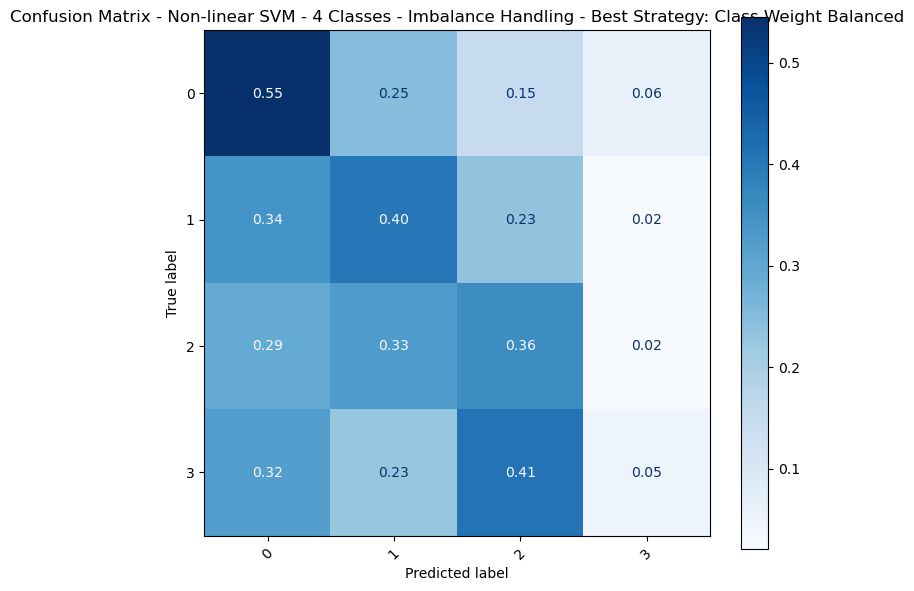


Classification report - Non-linear SVM - 4 Classes - Imbalance Handling - Best Strategy: Class Weight Balanced


,precision,recall,f1-score,support
0,0.795737,0.545344,0.647165,1643.000000
1,0.260479,0.401848,0.316076,433.000000
2,0.202222,0.358268,0.258523,254.000000
3,0.009259,0.045455,0.015385,22.000000
accuracy,0.494048,0.494048,0.494048,0.494048
macro avg,0.316924,0.337728,0.309287,2352.000000
weighted avg,0.625745,0.494048,0.538332,2352.000000



Classification report - Non-linear SVM - 4 Classes - Imbalance Handling - Class Weight Balanced


,precision,recall,f1-score,support
0,0.795737,0.545344,0.647165,1643.000000
1,0.260479,0.401848,0.316076,433.000000
2,0.202222,0.358268,0.258523,254.000000
3,0.009259,0.045455,0.015385,22.000000
accuracy,0.494048,0.494048,0.494048,0.494048
macro avg,0.316924,0.337728,0.309287,2352.000000
weighted avg,0.625745,0.494048,0.538332,2352.000000



Classification report - Non-linear SVM - 4 Classes - Imbalance Handling - SMOTE


...

,precision,recall,f1-score,support
0,0.780960,0.564212,0.655124,1643.000000
1,0.289100,0.140878,0.189441,433.000000
2,0.177903,0.374016,0.241117,254.000000
3,0.016667,0.318182,0.031674,22.000000
accuracy,0.463435,0.463435,0.463435,0.463435
macro avg,0.316157,0.349322,0.279339,2352.000000
weighted avg,0.618134,0.463435,0.518851,2352.000000



Classification report - Non-linear SVM - 4 Classes - Imbalance Handling - SMOTE + ENN


,precision,recall,f1-score,support
0,0.769416,0.584906,0.664592,1643.000000
1,0.247265,0.260970,0.253933,433.000000
2,0.199561,0.358268,0.256338,254.000000
3,0.021053,0.181818,0.037736,22.000000
accuracy,0.497024,0.497024,0.497024,0.497024
macro avg,0.309324,0.346490,0.303150,2352.000000
weighted avg,0.604748,0.497024,0.539038,2352.000000



Classification report - Non-linear SVM - 4 Classes - Imbalance Handling - ADASYN + ENN


,precision,recall,f1-score,support
0,0.853591,0.188071,0.308229,1643.00000
1,0.207137,0.616628,0.310105,433.00000
2,0.161667,0.381890,0.227166,254.00000
3,0.019802,0.090909,0.032520,22.00000
accuracy,0.286990,0.286990,0.286990,0.28699
macro avg,0.310549,0.319374,0.219505,2352.00000
weighted avg,0.652058,0.286990,0.297241,2352.00000


In [52]:
nonlinear_svm_4class_imbalance = run_svm_experiment(
    X=X,
    y=y_4class,
    problem_name="Non-linear SVM - 4 Classes - Imbalance Handling",
    kernel_type="nonlinear",
    imbalance=True,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)

Non-linear SVM - 3 Classes - No Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.117186
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.117347
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: No Imbalance Correction
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters:
{'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.39670675384353954

CV results:


,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
0,Non-linear SVM - 3 Classes - No Imbalance Hand...,nonlinear,False,No Imbalance Correction,0.396707,"{'clf__C': 10, 'clf__class_weight': None, 'clf..."



Best strategy:
No Imbalance Correction

Best parameters:
{'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.39670675384353954


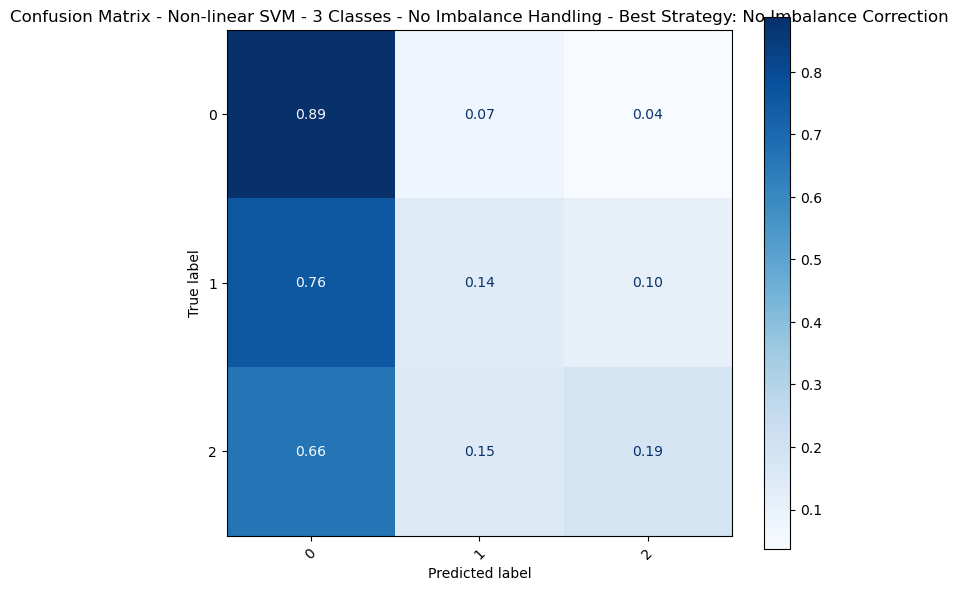


Classification report - Non-linear SVM - 3 Classes - No Imbalance Handling - Best Strategy: No Imbalance Correction


,precision,recall,f1-score,support
0,0.740609,0.888010,0.807639,1643.000000
1,0.267857,0.138568,0.182648,433.000000
2,0.329114,0.188406,0.239631,276.000000
accuracy,0.667942,0.667942,0.667942,0.667942
macro avg,0.445860,0.404995,0.409973,2352.000000
weighted avg,0.605288,0.667942,0.625925,2352.000000



Classification report - Non-linear SVM - 3 Classes - No Imbalance Handling - No Imbalance Correction


,precision,recall,f1-score,support
0,0.740609,0.888010,0.807639,1643.000000
1,0.267857,0.138568,0.182648,433.000000
2,0.329114,0.188406,0.239631,276.000000
accuracy,0.667942,0.667942,0.667942,0.667942
macro avg,0.445860,0.404995,0.409973,2352.000000
weighted avg,0.605288,0.667942,0.625925,2352.000000


In [53]:
nonlinear_svm_3class_no_imbalance = run_svm_experiment(
    X=X,
    y=y_3class,
    problem_name="Non-linear SVM - 3 Classes - No Imbalance Handling",
    kernel_type="nonlinear",
    imbalance=False,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)

Non-linear SVM - 3 Classes - Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.117186
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.117347
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: Class Weight Balanced
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters:
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.47793943378342085

------------------------------------------------------------------------------------------
Strategy: SMOTE
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 16 candidates, totalling 48 fits


,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
0,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,Class Weight Balanced,0.477939,"{'clf__C': 0.1, 'clf__class_weight': 'balanced..."
1,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE,0.464875,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
3,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE + Tomek,0.463783,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
5,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE + ENN,0.461906,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
2,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN,0.461323,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
4,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN + Tomek,0.461323,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
6,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN + ENN,0.442365,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."



Best strategy:
Class Weight Balanced

Best parameters:
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}

Best CV balanced accuracy:
0.47793943378342085


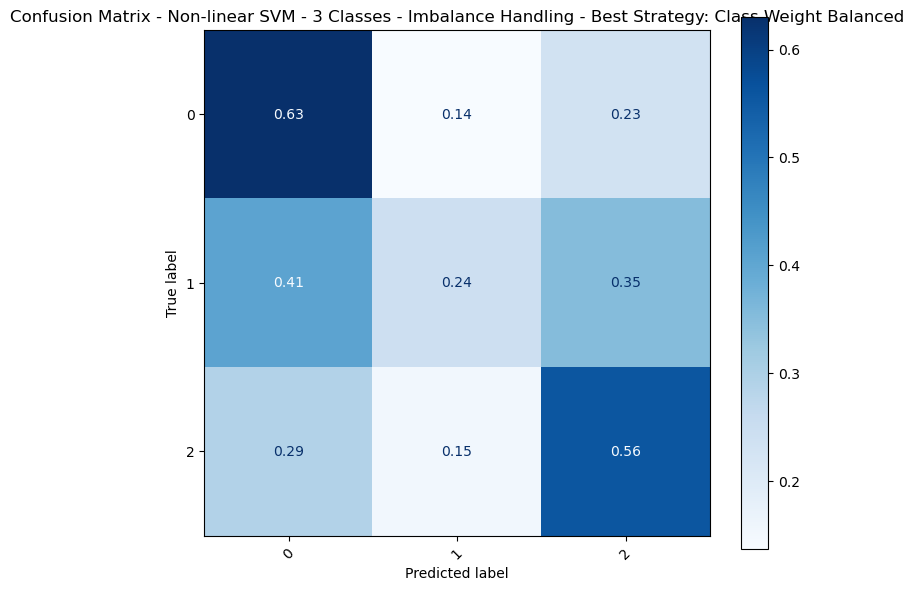


Classification report - Non-linear SVM - 3 Classes - Imbalance Handling - Best Strategy: Class Weight Balanced


,precision,recall,f1-score,support
0,0.801858,0.630554,0.705963,1643.000000
1,0.282258,0.242494,0.260870,433.000000
2,0.223837,0.557971,0.319502,276.000000
accuracy,0.550595,0.550595,0.550595,0.550595
macro avg,0.435984,0.477006,0.428778,2352.000000
weighted avg,0.638371,0.550595,0.578672,2352.000000



Classification report - Non-linear SVM - 3 Classes - Imbalance Handling - Class Weight Balanced


,precision,recall,f1-score,support
0,0.801858,0.630554,0.705963,1643.000000
1,0.282258,0.242494,0.260870,433.000000
2,0.223837,0.557971,0.319502,276.000000
accuracy,0.550595,0.550595,0.550595,0.550595
macro avg,0.435984,0.477006,0.428778,2352.000000
weighted avg,0.638371,0.550595,0.578672,2352.000000



Classification report - Non-linear SVM - 3 Classes - Imbalance Handling - SMOTE


...

,precision,recall,f1-score,support
0,0.793774,0.496652,0.611007,1643.000000
1,0.227964,0.346420,0.274977,433.000000
2,0.217718,0.525362,0.307856,276.000000
accuracy,0.472364,0.472364,0.472364,0.472364
macro avg,0.413152,0.456145,0.397947,2352.000000
weighted avg,0.622011,0.472364,0.513571,2352.000000



Classification report - Non-linear SVM - 3 Classes - Imbalance Handling - SMOTE + ENN


,precision,recall,f1-score,support
0,0.786898,0.606817,0.685223,1643.000000
1,0.257880,0.207852,0.230179,433.000000
2,0.210598,0.561594,0.306324,276.000000
accuracy,0.528061,0.528061,0.528061,0.528061
macro avg,0.418459,0.458754,0.407242,2352.000000
weighted avg,0.621880,0.528061,0.556988,2352.000000



Classification report - Non-linear SVM - 3 Classes - Imbalance Handling - ADASYN + ENN


,precision,recall,f1-score,support
0,0.779210,0.552039,0.646242,1643.000000
1,0.231982,0.237875,0.234892,433.000000
2,0.211022,0.568841,0.307843,276.000000
accuracy,0.496173,0.496173,0.496173,0.496173
macro avg,0.407404,0.452918,0.396325,2352.000000
weighted avg,0.611791,0.496173,0.530803,2352.000000


In [54]:
nonlinear_svm_3class_imbalance = run_svm_experiment(
    X=X,
    y=y_3class,
    problem_name="Non-linear SVM - 3 Classes - Imbalance Handling",
    kernel_type="nonlinear",
    imbalance=True,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)

In [55]:
nonlinear_svm_comparison = pd.concat(
    [
        nonlinear_svm_4class_no_imbalance["test_results_all"],
        nonlinear_svm_4class_imbalance["test_results_all"],
        nonlinear_svm_3class_no_imbalance["test_results_all"],
        nonlinear_svm_3class_imbalance["test_results_all"]
    ],
    ignore_index=True
)

nonlinear_svm_comparison = nonlinear_svm_comparison.sort_values(
    by="balanced_accuracy",
    ascending=False
)

nonlinear_svm_comparison

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,roc_auc_ovr_weighted,roc_auc_ovr_macro,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
9,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.550595,0.477006,0.638371,0.550595,0.578672,0.435984,0.477006,0.428778,0.674763,0.668123,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,Class Weight Balanced,0.477939,"{'clf__C': 0.1, 'clf__class_weight': 'balanced..."
10,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.500000,0.462220,0.627187,0.500000,0.538544,0.419664,0.462220,0.410774,0.648181,0.642485,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE + Tomek,0.463783,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
11,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.499150,0.461814,0.627204,0.499150,0.537871,0.419368,0.461814,0.410253,0.648024,0.642274,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE,0.464875,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
12,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.528061,0.458754,0.621880,0.528061,0.556988,0.418459,0.458754,0.407242,0.642079,0.635294,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,SMOTE + ENN,0.461906,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
13,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.472364,0.456145,0.622011,0.472364,0.513571,0.413152,0.456145,0.397947,0.641655,0.637501,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN + Tomek,0.461323,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
14,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.471514,0.455739,0.622131,0.471514,0.512880,0.412943,0.455739,0.397375,0.641684,0.637469,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN,0.461323,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
15,Non-linear SVM - 3 Classes - Imbalance Handlin...,0.496173,0.452918,0.611791,0.496173,0.530803,0.407404,0.452918,0.396325,0.636799,0.631709,Non-linear SVM - 3 Classes - Imbalance Handling,nonlinear,True,ADASYN + ENN,0.442365,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
8,Non-linear SVM - 3 Classes - No Imbalance Hand...,0.667942,0.404995,0.605288,0.667942,0.625925,0.445860,0.404995,0.409973,0.640173,0.617818,Non-linear SVM - 3 Classes - No Imbalance Hand...,nonlinear,False,No Imbalance Correction,0.396707,"{'clf__C': 10, 'clf__class_weight': None, 'clf..."
1,Non-linear SVM - 4 Classes - Imbalance Handlin...,0.464711,0.349778,0.619030,0.464711,0.519955,0.316997,0.349778,0.279860,0.615712,0.637984,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,ADASYN,0.358371,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
2,Non-linear SVM - 4 Classes - Imbalance Handlin...,0.463435,0.349322,0.618134,0.463435,0.518851,0.316157,0.349322,0.279339,0.615656,0.637982,Non-linear SVM - 4 Classes - Imbalance Handling,nonlinear,True,ADASYN + Tomek,0.358423,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."


In [56]:
best_nonlinear_svm_row = nonlinear_svm_comparison.iloc[0]

best_nonlinear_svm_row

model                        Non-linear SVM - 3 Classes - Imbalance Handlin...
accuracy                                                              0.550595
balanced_accuracy                                                     0.477006
precision_weighted                                                    0.638371
recall_weighted                                                       0.550595
f1_weighted                                                           0.578672
precision_macro                                                       0.435984
recall_macro                                                          0.477006
f1_macro                                                              0.428778
roc_auc_ovr_weighted                                                  0.674763
roc_auc_ovr_macro                                                     0.668123
problem                        Non-linear SVM - 3 Classes - Imbalance Handling
kernel_type                                         

Linear SVM - 3 Classes - No Imbalance Handling
Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.117186
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.117347
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------
Strategy: No Imbalance Correction
------------------------------------------------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x104955bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107b35bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106869bc0>
Traceback (most recent call last

Best parameters:
{'clf__C': 0.001, 'clf__class_weight': None, 'clf__kernel': 'linear'}

Best CV balanced accuracy:
0.3333333333333333

CV results:


,problem,kernel_type,imbalance,strategy,best_cv_balanced_accuracy,best_params
0,Linear SVM - 3 Classes - No Imbalance Handling,linear,False,No Imbalance Correction,0.333333,"{'clf__C': 0.001, 'clf__class_weight': None, '..."



Best strategy:
No Imbalance Correction

Best parameters:
{'clf__C': 0.001, 'clf__class_weight': None, 'clf__kernel': 'linear'}

Best CV balanced accuracy:
0.3333333333333333


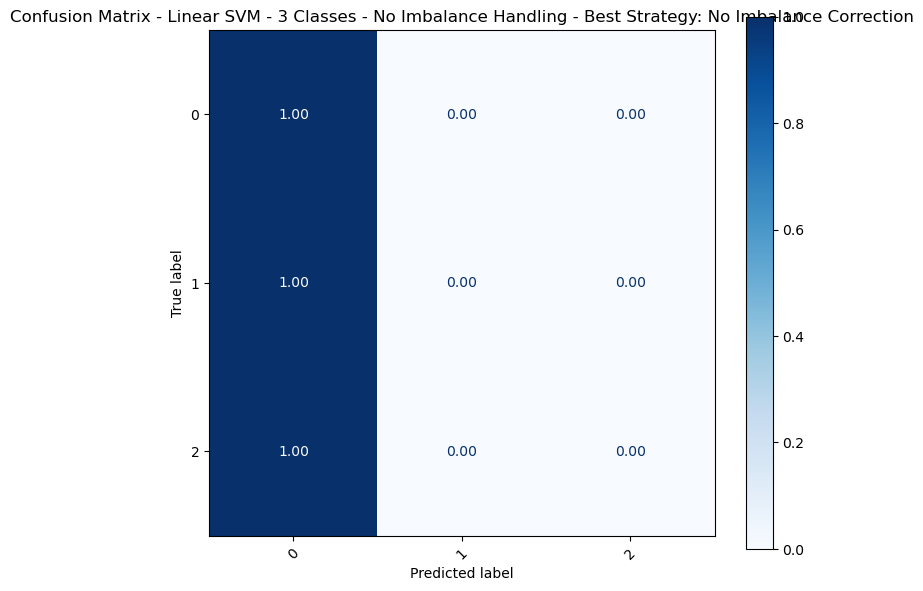


Classification report - Linear SVM - 3 Classes - No Imbalance Handling - Best Strategy: No Imbalance Correction


,precision,recall,f1-score,support
0,0.698554,1.000000,0.822528,1643.000000
1,0.000000,0.000000,0.000000,433.000000
2,0.000000,0.000000,0.000000,276.000000
accuracy,0.698554,0.698554,0.698554,0.698554
macro avg,0.232851,0.333333,0.274176,2352.000000
weighted avg,0.487978,0.698554,0.574581,2352.000000



Classification report - Linear SVM - 3 Classes - No Imbalance Handling - No Imbalance Correction


,precision,recall,f1-score,support
0,0.698554,1.000000,0.822528,1643.000000
1,0.000000,0.000000,0.000000,433.000000
2,0.000000,0.000000,0.000000,276.000000
accuracy,0.698554,0.698554,0.698554,0.698554
macro avg,0.232851,0.333333,0.274176,2352.000000
weighted avg,0.487978,0.698554,0.574581,2352.000000


In [9]:
#linear svm without imbalance handling
linear_svm_3class_imbalance = run_svm_experiment(
    X=X,
    y=y_3class,
    problem_name="Linear SVM - 3 Classes - No Imbalance Handling",
    kernel_type="linear",
    imbalance=False,
    test_size=0.3,
    random_state=42,
    cv=cv,
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False
)